# `find_small_clusters`
Identifies clusters of trapped voxels smaller than a given size and rolls them back to invaded. This is typically used to clean up pixel-scale noise after trapping analysis.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import porespy as ps

ps.visualization.set_mpl_style()

The arguments and their defaults are. Note that the function takes the original image *and* a separate boolean mask of the trapped voxels.

In [2]:
import inspect

inspect.signature(ps.filters.find_small_clusters)

<Signature (im: numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[~_ScalarT]], trapped: numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[~_ScalarT]] = None, min_size: int = 1, conn: str = 'min')>

Set up a drainage simulation with trapping so we have a realistic `trapped` mask to feed in. Trapping at the pixel scale typically produces some single- and few-voxel artefacts along solid walls.

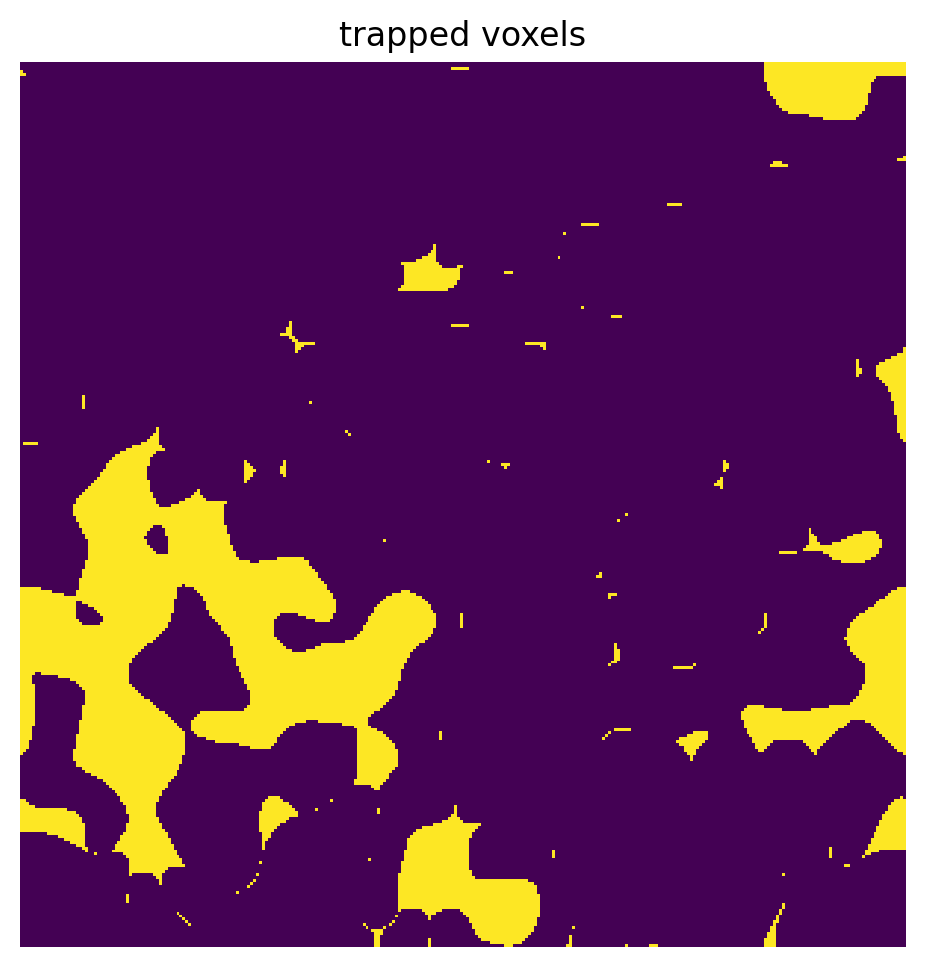

In [3]:
np.random.seed(0)
im = ps.generators.blobs(shape=[300, 300], porosity=0.65, seed=2)
im = ps.filters.fill_closed_pores(im)
inlets = ps.generators.faces(im.shape, inlet=0)
outlets = ps.generators.faces(im.shape, outlet=0)
pc = ps.filters.capillary_transform(
    im=im, sigma=0.072, theta=180, voxel_size=1e-5)
drn = ps.simulations.drainage(im=im, pc=pc, inlets=inlets, outlets=outlets)
trapped = drn.im_seq == -1

fig, ax = plt.subplots(figsize=[5, 5])
ax.imshow(trapped, origin='lower', interpolation='none')
ax.set_title('trapped voxels')
ax.axis(False);

## `min_size`
Trapped clusters with this many voxels or fewer are released. Larger values release more, until at some point only the largest trapped regions remain.

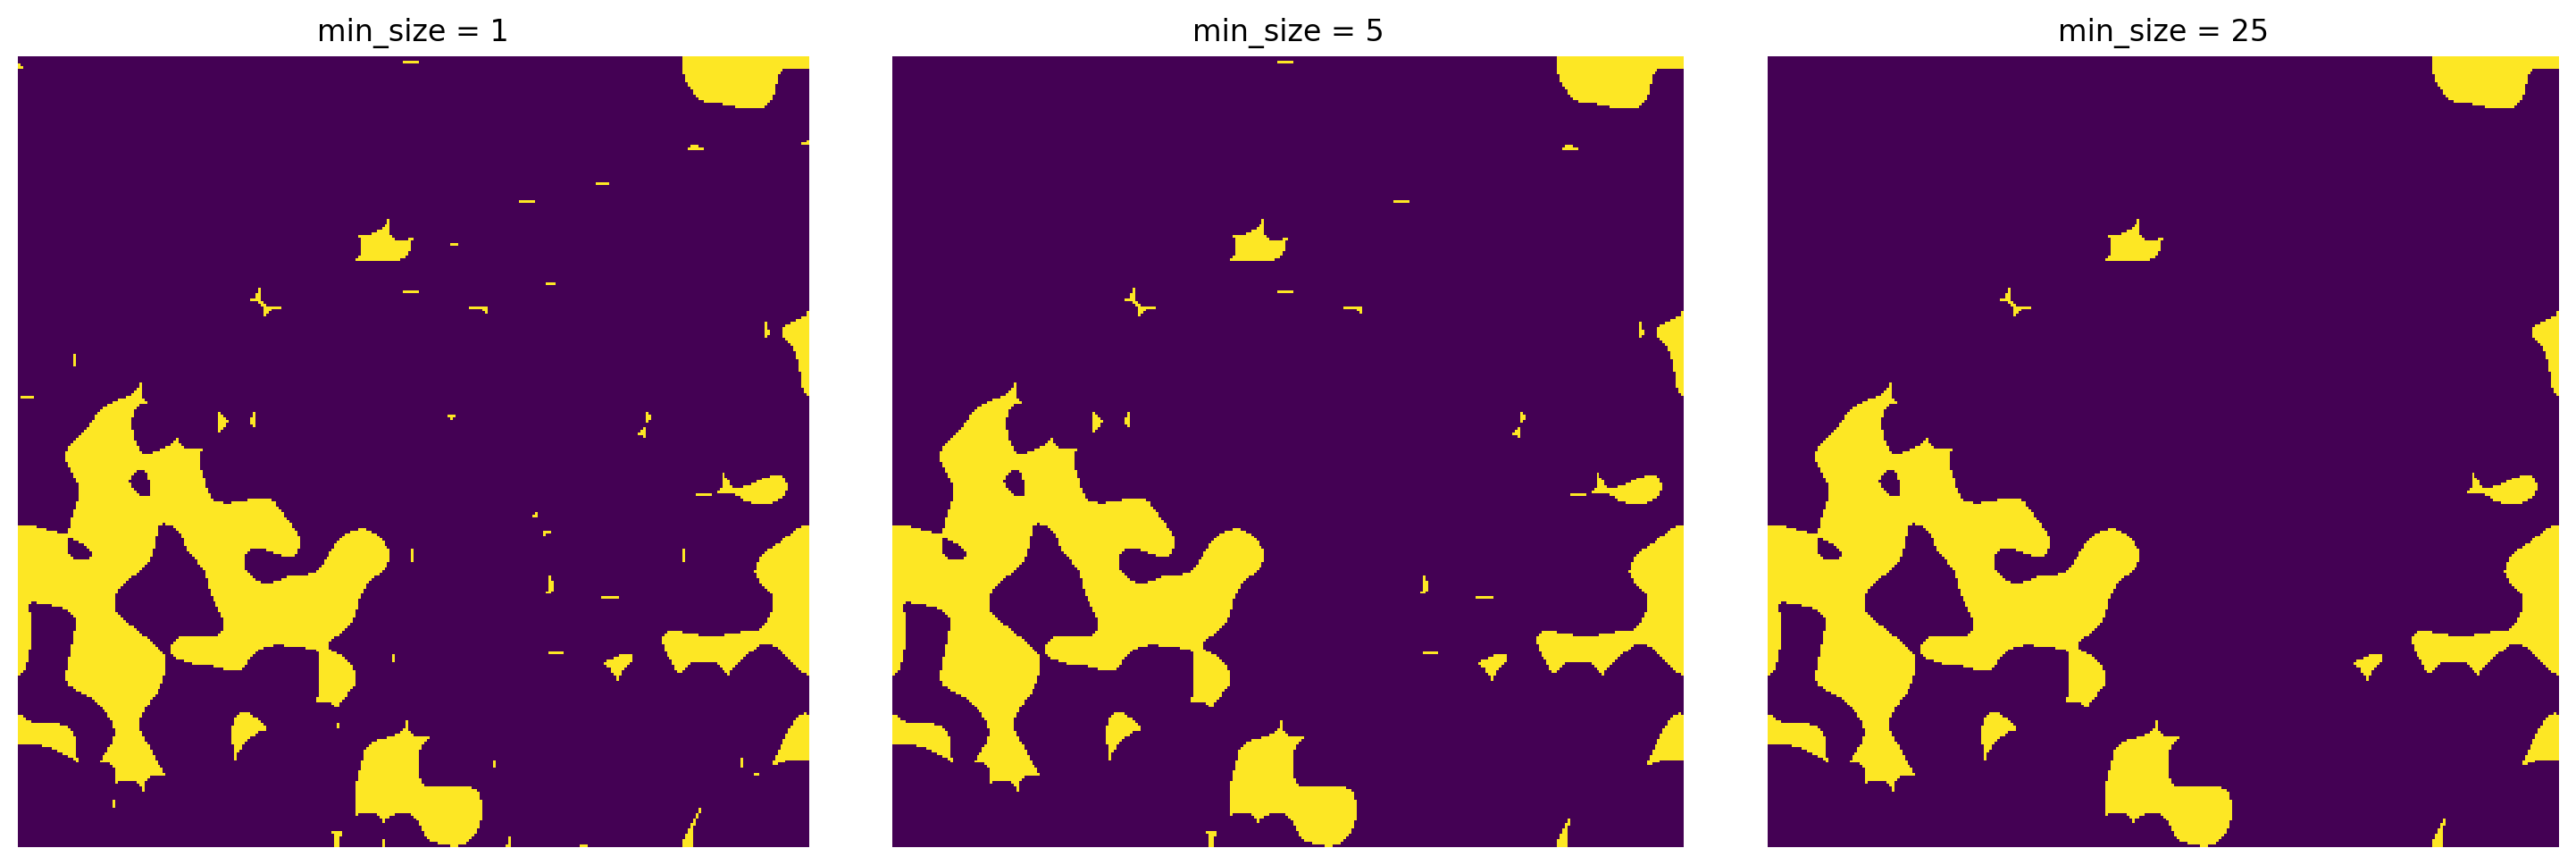

In [4]:
fig, ax = plt.subplots(1, 3, figsize=[15, 5])
for axis, min_size in zip(ax, [1, 5, 25]):
    res = ps.filters.find_small_clusters(
        im=im, trapped=trapped.copy(), min_size=min_size)
    axis.imshow(res.im_trapped, origin='lower', interpolation='none')
    axis.set_title(f'min_size = {min_size}')
    axis.axis(False)

## `conn`
Controls voxel connectivity used to define a cluster. `'min'` (default) requires shared faces; `'max'` accepts edges and corners. Looser connectivity merges neighbouring clusters and so reduces the number of voxels released for a given `min_size`.

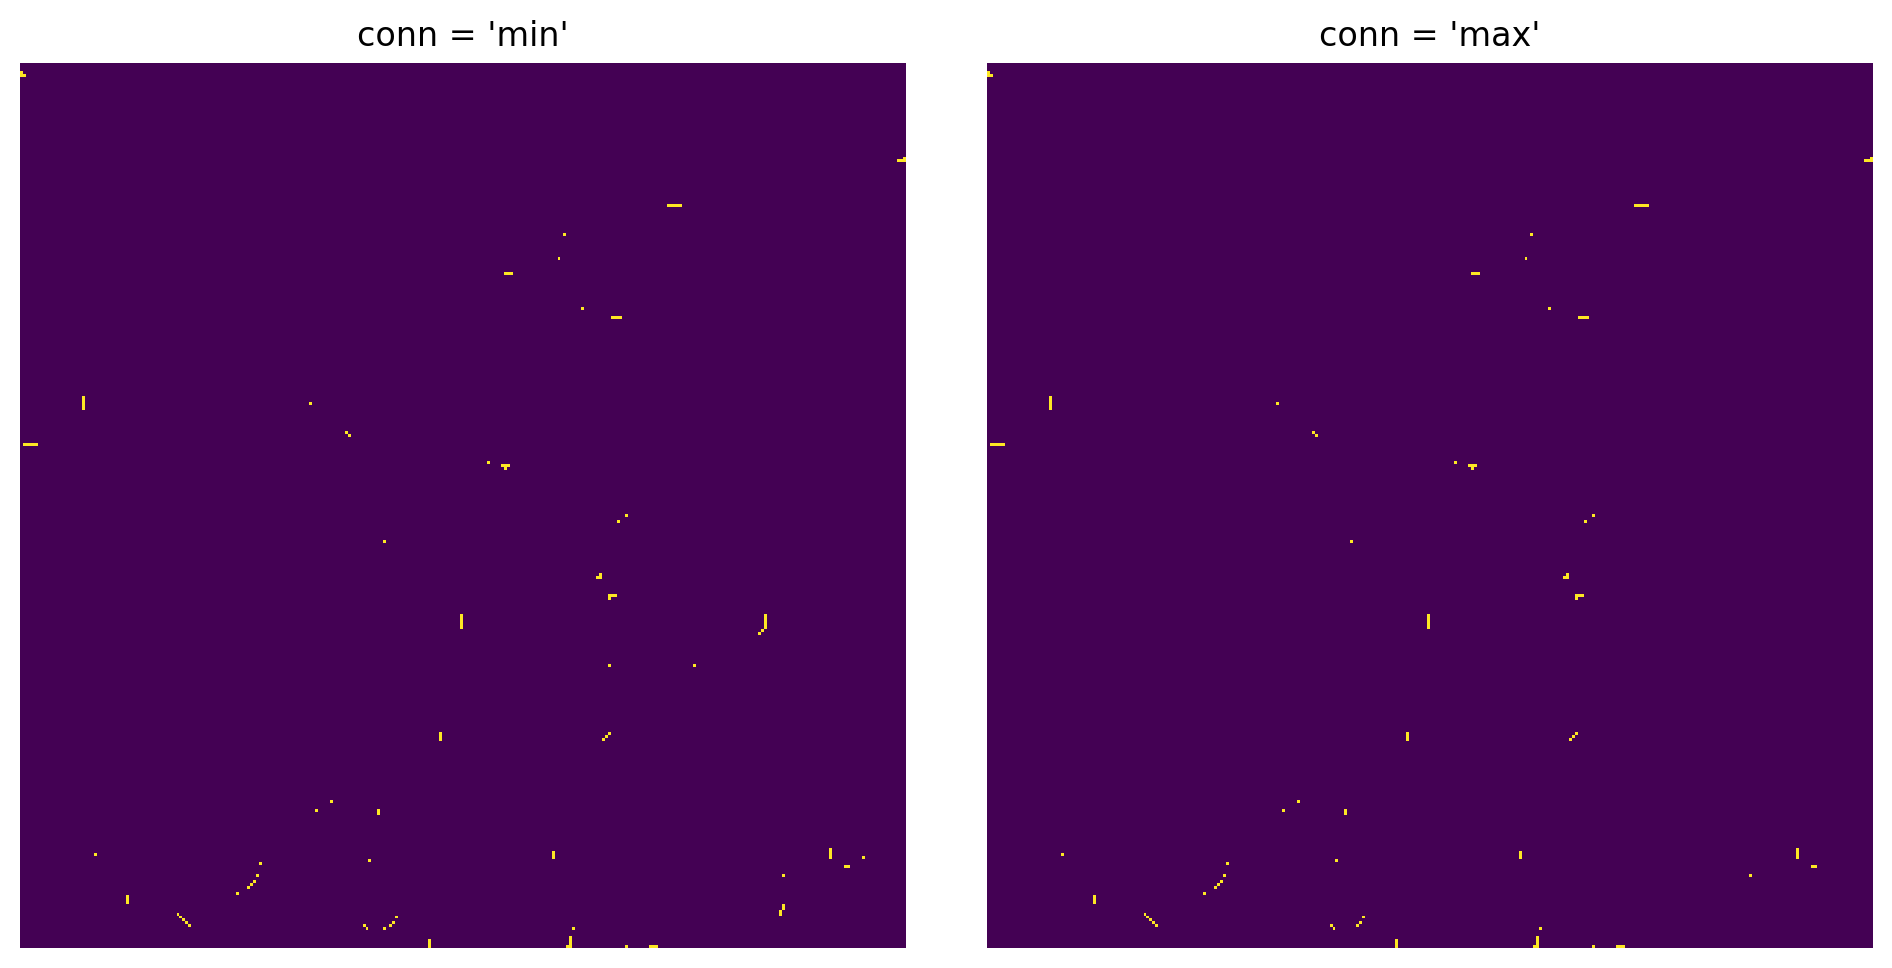

In [5]:
res_min = ps.filters.find_small_clusters(
    im=im, trapped=trapped.copy(), min_size=5, conn='min')
res_max = ps.filters.find_small_clusters(
    im=im, trapped=trapped.copy(), min_size=5, conn='max')

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(res_min.im_small, origin='lower', interpolation='none')
ax[0].set_title("conn = 'min'")
ax[0].axis(False)
ax[1].imshow(res_max.im_small, origin='lower', interpolation='none')
ax[1].set_title("conn = 'max'")
ax[1].axis(False);

## Returned attributes
`find_small_clusters` returns a `Results` object with two boolean images: `im_small` flags the released voxels, and `im_trapped` is the input mask with those voxels switched off.

In [6]:
res = ps.filters.find_small_clusters(
    im=im, trapped=trapped.copy(), min_size=5)
print('voxels released:', int(res.im_small.sum()))
print('voxels still trapped:', int(res.im_trapped.sum()))

voxels released: 124
voxels still trapped: 12155
